# Donde había una isla, ahora hay 850 metros de agua

El 15 de enero de 2022 el volcán Hunga, en Tonga, produjo una de las erupciones más explosivas del último siglo. Lo que pasó bajo el agua tardó meses en verse: cuando los barcos volvieron a mapear el fondo, el piso de la caldera había bajado de unos 150 m de profundidad a unos 850 m. En el punto que más se hundió —918 m— antes de la erupción había tierra firme, 68 m por encima del mar.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Ribó et al. (2026). *Rapid submarine caldera collapse during the 2022 climactic eruption of Hunga volcano (Tonga)*. **Nature Geoscience**

**DOI:** [10.1038/s41561-026-02099-7](https://doi.org/10.1038/s41561-026-02099-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-11-hunga-caldera-colapso-submarino/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/BJz_pMfqcZc)

## Un volcán que casi nadie ve

Hunga es un estratovolcán de unos 1.800 m de altura del que solo asomaban dos islas de menos de 140 m: Hunga Ha'apai al noroeste y Hunga Tonga al noreste. Entre 2014 y 2015 una erupción levantó un cono de ceniza de 2 km que las unió. En 2022, tras unas 11 horas de explosiones donde el magma se encontraba con el agua de mar, la cima entera se vino abajo.

Una caldera no es el hueco que deja una explosión. Es el techo de la cámara de magma que se desploma cuando la cámara se vacía por debajo. Verlo ocurrir bajo el mar es rarísimo: hace falta haber mapeado el fondo *antes* con buena resolución, y volver *después*. Aquí tenemos las dos cosas.

Lo que vamos a abrir:

- **Dos modelos del fondo marino** a 50 m de resolución (sonar multihaz): uno de 2015-2016 y otro de abril-octubre de 2022. Restarlos nos dice cuánto bajó cada celda del fondo.
- **Tres cortes** por el centro de la caldera, para ver la forma del hundimiento.
- **13 sondeos** de una campaña de abril de 2022 que midieron la profundidad con un instrumento distinto — un control independiente.
- **Una base de 177 calderas del mundo** que el propio paper compiló, para saber si Hunga es normal o rara.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERFIL_HERO = 'NW-SE'        # corte que pasa por el punto de máximo hundimiento ('E-W', 'N-S', 'NW-SE')
RADIO_COLAPSO_KM = 4.0       # radio para sumar el volumen que se perdió en la caldera
RADIO_CUADRANTES_KM = 2.5    # radio para comparar los cuatro cuadrantes
UMBRAL_RUIDO_M = 20          # cambios menores que esto son ruido entre campañas
UMBRAL_HUNDIDO_M = 50        # una celda "se hundió" si bajó más que esto
HUNGA_DIAM_KM = 4.0          # diámetro estructural de Hunga según el paper (4 ± 0,4 km)
HUNGA_SUBSID_KM = 1.0        # subsidencia estructural de Hunga según el paper (1,0 ± 0,2 km)

FUENTE = ('Fuente: Ribó et al. (2026), Nature Geoscience | '
          'Datos: Zenodo 10.5281/zenodo.7456324 + Source Data del paper')
COLOR_DATOS = '#2563EB'        # azul CaM
COLOR_ALERTA = '#DC2626'       # rojo
COLOR_SECUNDARIO = '#059669'   # verde
COLOR_REFERENCIA = '#D97706'   # ámbar
COLOR_CONTEXTO = '#BBBBBB'     # gris

# ── Setup ──────────────────────────────────────────────────────
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter
from scipy import stats

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-09-11-hunga-caldera-colapso-submarino')

# Estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)


def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


# ── Carga ──────────────────────────────────────────────────────
grilla = cargar('cambio_fondo_caldera.csv')       # celdas de 100 m, ±5 km del centro
perfiles = cargar('perfiles_caldera.csv')         # tres cortes a 50 m
ctd = cargar('estaciones_ctd_abril2022.csv')      # 13 sondeos independientes
calderas = cargar('calderas_globales.csv')        # 177 calderas del mundo (incluye Hunga)

# Profundidades: negativo = bajo el nivel del mar. cambio_m = después − antes (negativo = bajó)
CELDA_KM = 0.1
grilla['r_km'] = np.hypot(grilla.x_km, grilla.y_km)

# El paper compara Hunga contra el resto: la separamos de la base global
hunga = calderas[calderas.caldera == 'Hunga'].iloc[0]
otras = calderas[calderas.caldera != 'Hunga'].copy()

print(f'Grilla: {len(grilla):,} celdas de 100 m'.replace(',', '.'),
      f'| x: {grilla.x_km.min():.1f}…{grilla.x_km.max():.1f} km | y: {grilla.y_km.min():.1f}…{grilla.y_km.max():.1f} km')
print(f'Perfiles: {perfiles.perfil.unique().tolist()} ({len(perfiles)} puntos a 50 m)')
print(f'CTD abril 2022: {len(ctd)} estaciones, {ctd.prof_m.min()}–{ctd.prof_m.max()} m')
print(f'Calderas globales: {len(calderas)} filas (Hunga + {len(otras)} otras)')
print(f'Hunga en la base: diámetro {hunga.diam_prom_km} km · subsidencia {hunga.subsidencia_km} km · s/d = {hunga.s_d:.2f}')

Grilla: 9.823 celdas de 100 m | x: -5.0…4.9 km | y: -4.9…5.0 km
Perfiles: ['E-W', 'N-S', 'NW-SE'] (584 puntos a 50 m)
CTD abril 2022: 13 estaciones, 89–852 m
Calderas globales: 177 filas (Hunga + 176 otras)
Hunga en la base: diámetro 4.0 km · subsidencia 1.0 km · s/d = 0.25


## Un corte por el medio

Aquí está.

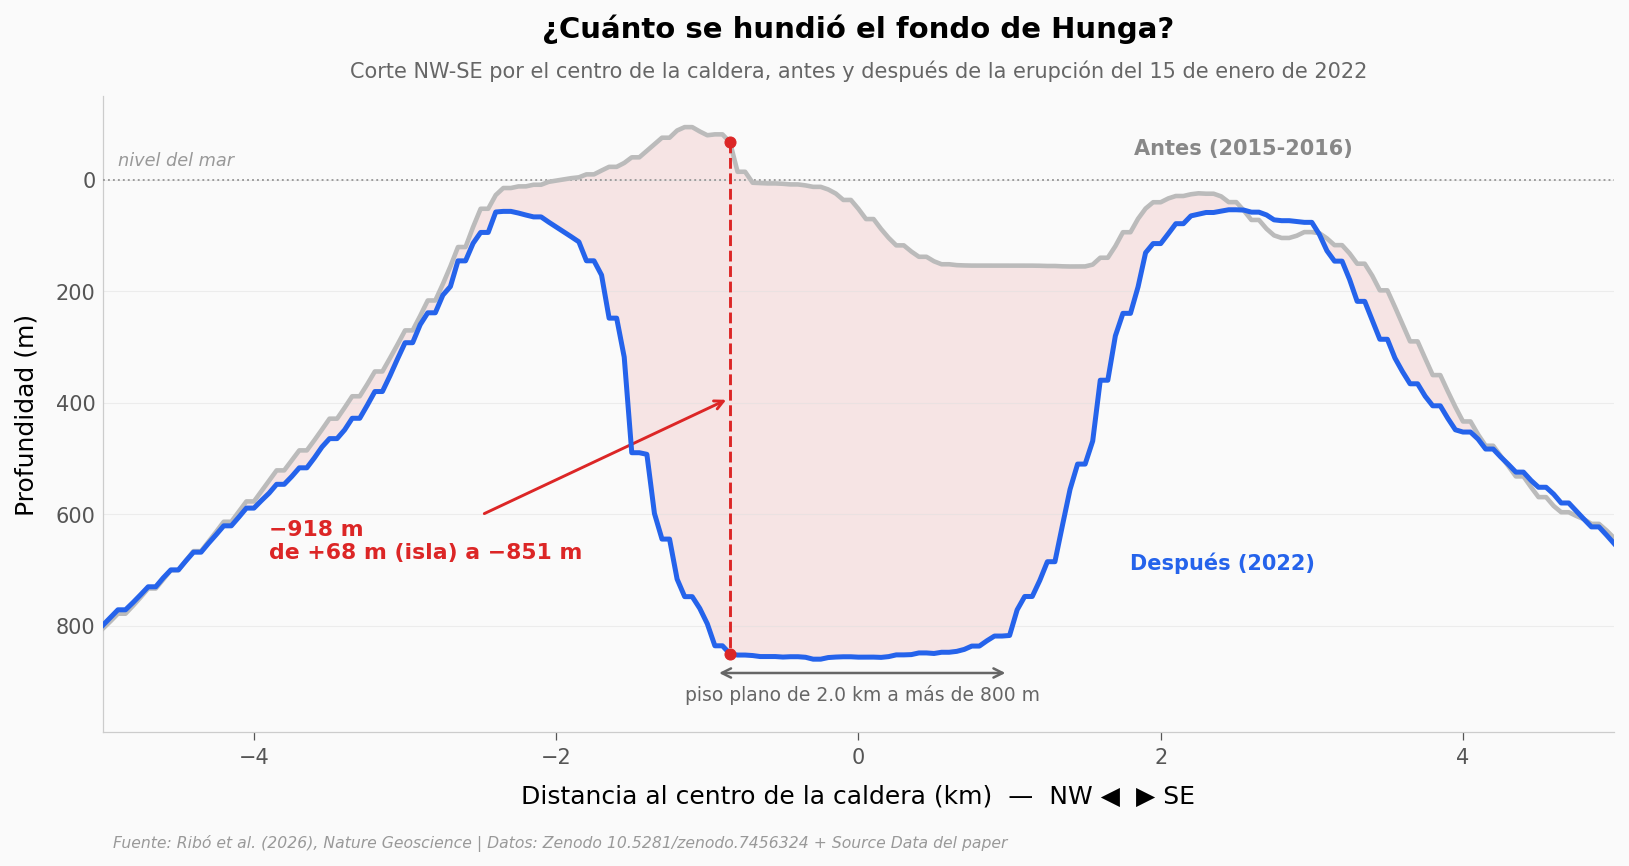

Perfil NW-SE: caída máxima 918 m en d = -0.85 km (antes +68 m, después -851 m)
Fondo ANTES dentro de ±2 km: mínimo -156 m · DESPUÉS: mínimo -860 m
Bordes después: -57 m (d=-2.35) y -54 m (d=+2.45) → 4.80 km de borde a borde
Cuánto bajaron los bordes: NW -42 m · SE -14 m
Piso contiguo más hondo que 800 m: 2.00 km
Escalones del lado NW (cotas donde el corte se aplana): 57 m, 66 m, 145 m, 248 m, 490 m, 645 m, 748 m, 836 m
Piso DESPUÉS en r ≤ 1 km (grilla): mediana -848 m, IQR -826…-855 m
Sondeos CTD más hondos (abril 2022): est. 17 a 852 m, est. 11 a 845 m, est. 8 a 844 m


In [2]:
perfil = perfiles[perfiles.perfil == PERFIL_HERO].sort_values('dist_km').reset_index(drop=True)
caida = perfil.prof_post_m - perfil.prof_pre_m
i_max = caida.idxmin()
d_max, pre_max, post_max = perfil.loc[i_max, ['dist_km', 'prof_pre_m', 'prof_post_m']]

# Piso plano: tramo contiguo alrededor del centro más profundo que 800 m
i0 = perfil.dist_km.abs().idxmin()
hondo = perfil.prof_post_m < -800
l = r = i0
while l - 1 >= 0 and hondo[l - 1]:
    l -= 1
while r + 1 < len(perfil) and hondo[r + 1]:
    r += 1
ancho_piso = perfil.dist_km[r] - perfil.dist_km[l] + 0.05

# Bordes: el punto más somero a cada lado dentro de ±3,5 km
izq = perfil[(perfil.dist_km < 0) & (perfil.dist_km >= -3.5)]
der = perfil[(perfil.dist_km > 0) & (perfil.dist_km <= 3.5)]
rim_izq, rim_der = izq.loc[izq.prof_post_m.idxmax()], der.loc[der.prof_post_m.idxmax()]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.fill_between(perfil.dist_km, perfil.prof_pre_m, perfil.prof_post_m,
                where=perfil.prof_post_m < perfil.prof_pre_m,
                color=COLOR_ALERTA, alpha=0.10, lw=0)
ax.plot(perfil.dist_km, perfil.prof_pre_m, color=COLOR_CONTEXTO, lw=2.2, zorder=4)
ax.plot(perfil.dist_km, perfil.prof_post_m, color=COLOR_DATOS, lw=2.4, zorder=5)
ax.axhline(0, color='#999999', lw=0.9, ls=':', zorder=3)
ax.text(-4.9, 18, 'nivel del mar', fontsize=8.5, color='#999999', style='italic', va='bottom')

# Inline labels
ax.text(2.55, 45, 'Antes (2015-2016)', fontsize=10, fontweight='bold', color='#888888', ha='center')
ax.text(1.8, -700, 'Después (2022)', fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='left')

# Punto de máxima caída
ax.plot([d_max, d_max], [pre_max, post_max], color=COLOR_ALERTA, lw=1.4, ls='--', zorder=6)
ax.scatter([d_max, d_max], [pre_max, post_max], color=COLOR_ALERTA, s=28, zorder=7)
ax.annotate(f'−{-(post_max - pre_max):.0f} m\nde +{pre_max:.0f} m (isla) a −{abs(post_max):.0f} m',
            xy=(d_max, (pre_max + post_max) / 2), xytext=(-3.9, -680),
            fontsize=10.5, fontweight='bold', color=COLOR_ALERTA, ha='left',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))

# Piso plano
ax.annotate('', xy=(perfil.dist_km[l], -885), xytext=(perfil.dist_km[r], -885),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.2))
ax.text((perfil.dist_km[l] + perfil.dist_km[r]) / 2, -935,
        f'piso plano de {ancho_piso:.1f} km a más de 800 m', fontsize=9, color='#666666', ha='center')

ax.set_xlim(-5, 5)
ax.set_ylim(-990, 150)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{abs(v):.0f}'))
ax.set_xlabel('Distancia al centro de la caldera (km)  —  NW ◀  ▶ SE')
ax.set_ylabel('Profundidad (m)')
ax.set_title('¿Cuánto se hundió el fondo de Hunga?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Corte {PERFIL_HERO} por el centro de la caldera, antes y después de la erupción del 15 de enero de 2022',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perfil_caldera.png', dpi=200, bbox_inches='tight')
plt.show()

dentro = perfil[perfil.dist_km.abs() <= 2]
print(f'Perfil {PERFIL_HERO}: caída máxima {-(post_max - pre_max):.0f} m en d = {d_max:+.2f} km (antes {pre_max:+.0f} m, después {post_max:.0f} m)')
print(f'Fondo ANTES dentro de ±2 km: mínimo {dentro.prof_pre_m.min():.0f} m · DESPUÉS: mínimo {perfil.prof_post_m.min():.0f} m')
print(f'Bordes después: {rim_izq.prof_post_m:.0f} m (d={rim_izq.dist_km:+.2f}) y {rim_der.prof_post_m:.0f} m (d={rim_der.dist_km:+.2f}) → {rim_der.dist_km - rim_izq.dist_km:.2f} km de borde a borde')
print(f'Cuánto bajaron los bordes: NW {rim_izq.prof_post_m - rim_izq.prof_pre_m:.0f} m · SE {rim_der.prof_post_m - rim_der.prof_pre_m:.0f} m')
print(f'Piso contiguo más hondo que 800 m: {ancho_piso:.2f} km')

# Escalones del lado NW: profundidades donde el corte se aplana (dos puntos seguidos a la misma cota)
lado = perfil[(perfil.dist_km >= -2.4) & (perfil.dist_km <= -0.9)].prof_post_m.values
mesetas = sorted({round(abs(a)) for a, b in zip(lado[:-1], lado[1:]) if a == b}, reverse=False)
print('Escalones del lado NW (cotas donde el corte se aplana):', ', '.join(f'{m} m' for m in mesetas))

centro = grilla[grilla.r_km <= 1]
print(f'Piso DESPUÉS en r ≤ 1 km (grilla): mediana {centro.prof_post_m.median():.0f} m, IQR {centro.prof_post_m.quantile(0.75):.0f}…{centro.prof_post_m.quantile(0.25):.0f} m')
hondas = ctd.nlargest(3, 'prof_m')
print('Sondeos CTD más hondos (abril 2022):', ', '.join(f'est. {int(e)} a {int(d)} m' for e, d in zip(hondas.estacion, hondas.prof_m)))

Lo que llama la atención no es solo la profundidad: es la forma. Antes, el fondo dentro de la caldera oscilaba entre los 155 m de profundidad y tierra firme. Después hay un piso casi horizontal de 2 km de ancho a más de 800 m, con el punto más hondo a 860 m. El paper habla de un fondo que pasó de ~150 m a ~850 m; nuestro corte lo reproduce.

El punto que más cayó, 918 m, estaba 68 m *por encima* del mar. Era parte del cono que la erupción de 2014-2015 había levantado entre las dos islas — y justo ahí, según los autores, empezó la erupción de 2022.

Los bordes, en cambio, bajaron poco —42 m el del NW y 14 m el del SE, frente a los 918 m del centro— y quedaron a 57 m y 54 m de profundidad, 4,8 km de distancia entre ellos. Eso es lo que distingue un colapso de un cráter: el hueco no se abrió hacia afuera, el centro se fue hacia abajo. Y desde el borde (57 m), bajando por el lado NW el corte se aplana una y otra vez — a 66, 145, 248, 490, 645 y 748 m — antes de llegar al piso a 836 m. Los autores los interpretan como fallas normales — fracturas por las que un bloque resbala hacia abajo — que se desprenden del bloque central mientras se hunde como un pistón (*piston subsidence*). El corte los muestra; lo que no puede decirnos es cómo se rompieron.

## De la línea al mapa

Un corte es una sola línea. Restando los dos modelos del fondo celda por celda podemos ver el hundimiento entero desde arriba — y sumarlo para saber cuánto material desapareció.

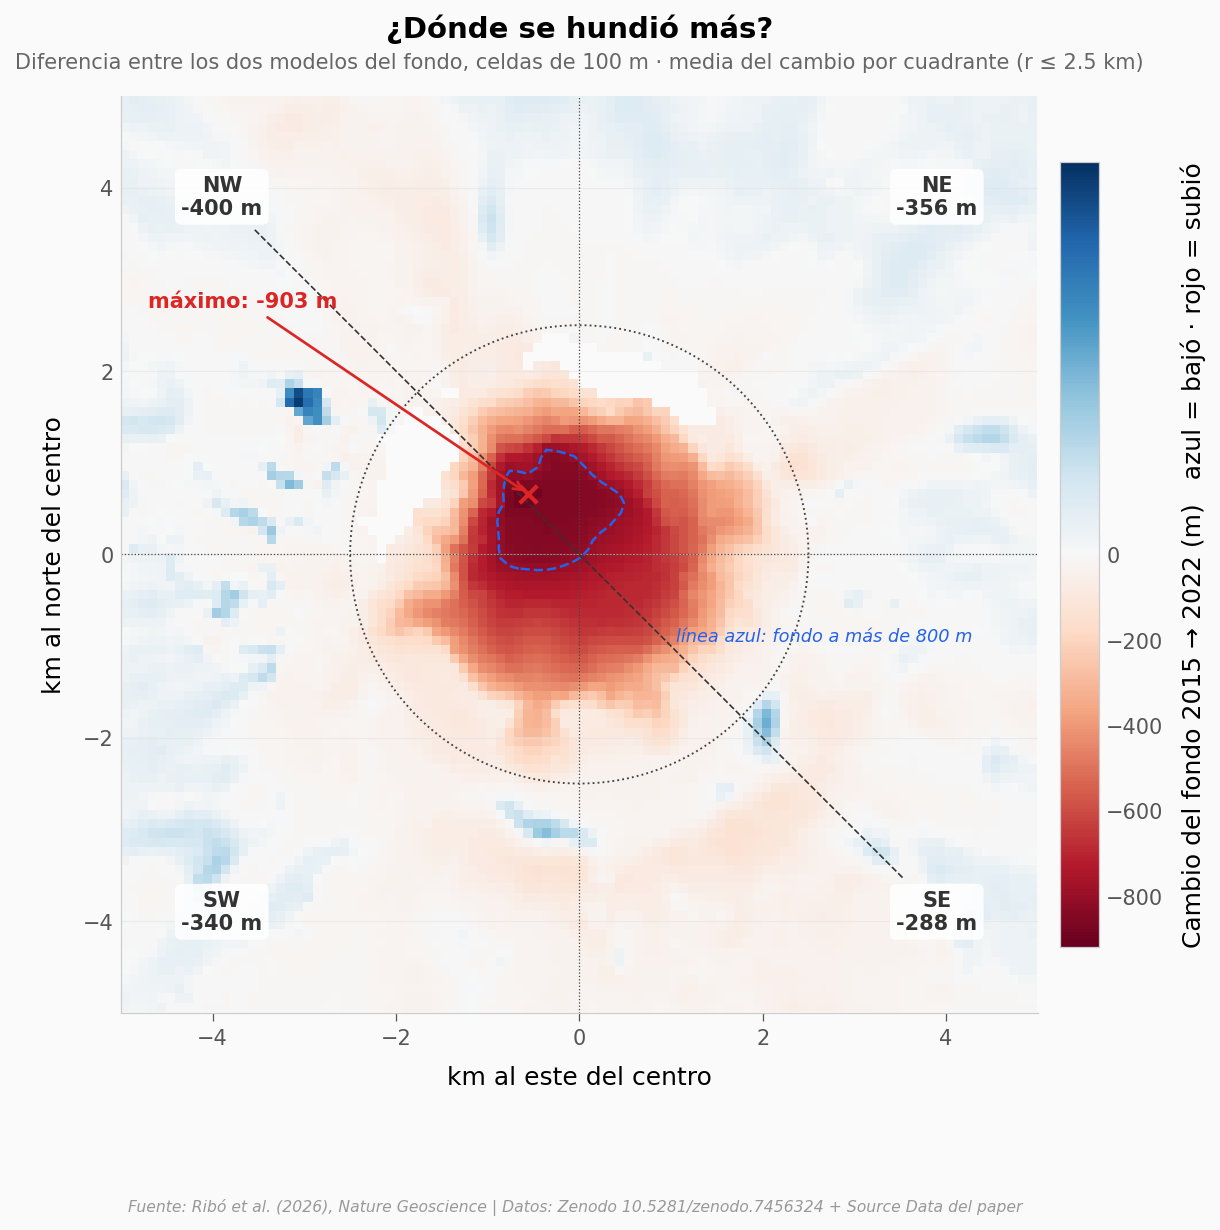

Máximo hundimiento en la grilla de 100 m: -903 m en x=-0.56, y=+0.66 km (cuadrante NW)
Área que bajó más de 800 m: 1.3 km²

Por cuadrante (r ≤ 2.5 km):
           media_m  min_m  vol_km3
cuadrante                         
NW         -400.12 -903.2     1.53
NE         -355.88 -846.9     1.50
SW         -340.39 -828.1     1.67
SE         -288.39 -795.2     1.44

Volumen perdido en r ≤ 4 km: 6.97 km³ (6.85 km³ ignorando cambios menores de 20 m) · ganado: 0.04 km³
Paper: 6,85 ± 0,05 km³ atribuidos al colapso → diferencia +1.7%
En toda la ventana de 10 × 10 km: perdido 7.49 km³ · ganado 0.17 km³ (el paper reporta 7,7 km³ dentro del borde y 8,9 km³ en total)
Ruido entre campañas (r > 4,5 km): mediana +0.2 m, IQR -14…+5 m, 20% de celdas con |cambio| > 20 m


In [3]:
piv = grilla.pivot(index='y_km', columns='x_km', values='cambio_m')
X, Y = piv.columns.values, piv.index.values

# Cuadrantes dentro de RADIO_CUADRANTES_KM
grilla['cuadrante'] = np.where(grilla.y_km >= 0,
                               np.where(grilla.x_km < 0, 'NW', 'NE'),
                               np.where(grilla.x_km < 0, 'SW', 'SE'))
en_r = grilla[grilla.r_km <= RADIO_CUADRANTES_KM]
cuad = (en_r.groupby('cuadrante')
        .agg(media_m=('cambio_m', 'mean'), min_m=('cambio_m', 'min'),
             vol_km3=('cambio_m', lambda s: -s[s < 0].sum() * CELDA_KM**2 / 1000))
        .reindex(['NW', 'NE', 'SW', 'SE']))

i_min = grilla.cambio_m.idxmin()
x_min, y_min, c_min = grilla.loc[i_min, ['x_km', 'y_km', 'cambio_m']]

fig, ax = plt.subplots(figsize=(9.5, 8.5))
norm = TwoSlopeNorm(vmin=-920, vcenter=0, vmax=90)
im = ax.pcolormesh(X, Y, piv.values, cmap='RdBu', norm=norm, shading='nearest')
ax.contour(X, Y, piv.values, levels=[-800], colors=[COLOR_DATOS], linewidths=1.2, linestyles='--')

# Círculo de cuadrantes y etiquetas con la media de cada uno
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(RADIO_CUADRANTES_KM * np.cos(theta), RADIO_CUADRANTES_KM * np.sin(theta),
        color='#444444', lw=0.9, ls=':')
ax.axhline(0, color='#444444', lw=0.6, ls=':')
ax.axvline(0, color='#444444', lw=0.6, ls=':')
pos = {'NW': (-3.9, 3.9), 'NE': (3.9, 3.9), 'SW': (-3.9, -3.9), 'SE': (3.9, -3.9)}
for q, (px, py) in pos.items():
    ax.text(px, py, f'{q}\n{cuad.loc[q, "media_m"]:.0f} m', fontsize=10, fontweight='bold',
            color='#333333', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.85))

# Corte del hero, para ubicarlo
if PERFIL_HERO == 'NW-SE':
    ax.plot([-3.54, 3.54], [3.54, -3.54], color='#333333', lw=0.8, ls='--')
elif PERFIL_HERO == 'E-W':
    ax.plot([-5, 5], [0, 0], color='#333333', lw=0.8, ls='--')
else:
    ax.plot([0, 0], [-5, 5], color='#333333', lw=0.8, ls='--')

ax.scatter([x_min], [y_min], marker='x', s=70, color=COLOR_ALERTA, lw=2, zorder=6)
ax.annotate(f'máximo: {c_min:.0f} m', xy=(x_min, y_min), xytext=(-4.7, 2.7),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
ax.text(1.05, -0.95, 'línea azul: fondo a más de 800 m', fontsize=8.5, color=COLOR_DATOS, style='italic')

cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label('Cambio del fondo 2015 → 2022 (m)   azul = bajó · rojo = subió')
ax.set_aspect('equal')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('km al este del centro')
ax.set_ylabel('km al norte del centro')
ax.set_title('¿Dónde se hundió más?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Diferencia entre los dos modelos del fondo, celdas de 100 m · media del cambio por cuadrante (r ≤ {RADIO_CUADRANTES_KM:.1f} km)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_cambio.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Volumen perdido ────────────────────────────────────────────
dentro_r = grilla[grilla.r_km <= RADIO_COLAPSO_KM]
vol_perdido = -dentro_r.loc[dentro_r.cambio_m < 0, 'cambio_m'].sum() * CELDA_KM**2 / 1000
vol_perdido_filtrado = -dentro_r.loc[dentro_r.cambio_m < -UMBRAL_RUIDO_M, 'cambio_m'].sum() * CELDA_KM**2 / 1000
vol_ganado = dentro_r.loc[dentro_r.cambio_m > 0, 'cambio_m'].sum() * CELDA_KM**2 / 1000
borde = grilla[grilla.r_km > 4.5]
area_800 = (grilla.cambio_m < -800).sum() * CELDA_KM**2

print(f'Máximo hundimiento en la grilla de 100 m: {c_min:.0f} m en x={x_min:+.2f}, y={y_min:+.2f} km (cuadrante {grilla.loc[i_min, "cuadrante"]})')
print(f'Área que bajó más de 800 m: {area_800:.1f} km²')
print()
print('Por cuadrante (r ≤ {:.1f} km):'.format(RADIO_CUADRANTES_KM))
print(cuad.round(2).to_string())
print()
print(f'Volumen perdido en r ≤ {RADIO_COLAPSO_KM:.0f} km: {vol_perdido:.2f} km³ '
      f'({vol_perdido_filtrado:.2f} km³ ignorando cambios menores de {UMBRAL_RUIDO_M} m) · ganado: {vol_ganado:.2f} km³')
print(f'Paper: 6,85 ± 0,05 km³ atribuidos al colapso → diferencia {100 * (vol_perdido / 6.85 - 1):+.1f}%')
vent_perdido = -grilla.loc[grilla.cambio_m < 0, 'cambio_m'].sum() * CELDA_KM**2 / 1000
vent_ganado = grilla.loc[grilla.cambio_m > 0, 'cambio_m'].sum() * CELDA_KM**2 / 1000
print(f'En toda la ventana de 10 × 10 km: perdido {vent_perdido:.2f} km³ · ganado {vent_ganado:.2f} km³ (el paper reporta 7,7 km³ dentro del borde y 8,9 km³ en total)')
print(f'Ruido entre campañas (r > 4,5 km): mediana {borde.cambio_m.median():+.1f} m, '
      f'IQR {borde.cambio_m.quantile(0.25):.0f}…{borde.cambio_m.quantile(0.75):+.0f} m, '
      f'{100 * (borde.cambio_m.abs() > UMBRAL_RUIDO_M).mean():.0f}% de celdas con |cambio| > {UMBRAL_RUIDO_M} m')

El hundimiento no es un plato uniforme: el cuadrante NW bajó 400 m en promedio y el SE, 288 m. Ahí, en el NW, está el máximo de la grilla (903 m — la celda de 100 m promedia lo que el corte a 50 m veía como 918 m). Y aun así el cuadrante que perdió más *volumen* es el SW, con 1,67 km³, porque tiene más área hundida. Hundirse más hondo y perder más material no son lo mismo.

Sumando todas las celdas en un radio de 4 km, desaparecieron 6,97 km³ de roca y sedimento — 6,85 km³ si ignoramos los cambios menores de 20 m, que en los bordes de la ventana (lejos de la caldera) son puro ruido entre campañas. El paper atribuye al colapso 6,85 ± 0,05 km³, con un modelo geométrico distinto al nuestro. Coincide al 2%. Los 8,9 km³ totales que reporta el paper incluyen 1,2 km³ erosionados del flanco sur, fuera de esta ventana de 10 × 10 km.

Ahora la pregunta de fondo. Una caldera de 4 km de diámetro que se hunde 1 km: ¿eso es normal? El paper compiló 177 calderas del mundo para responderlo. Veamos dónde cae Hunga.

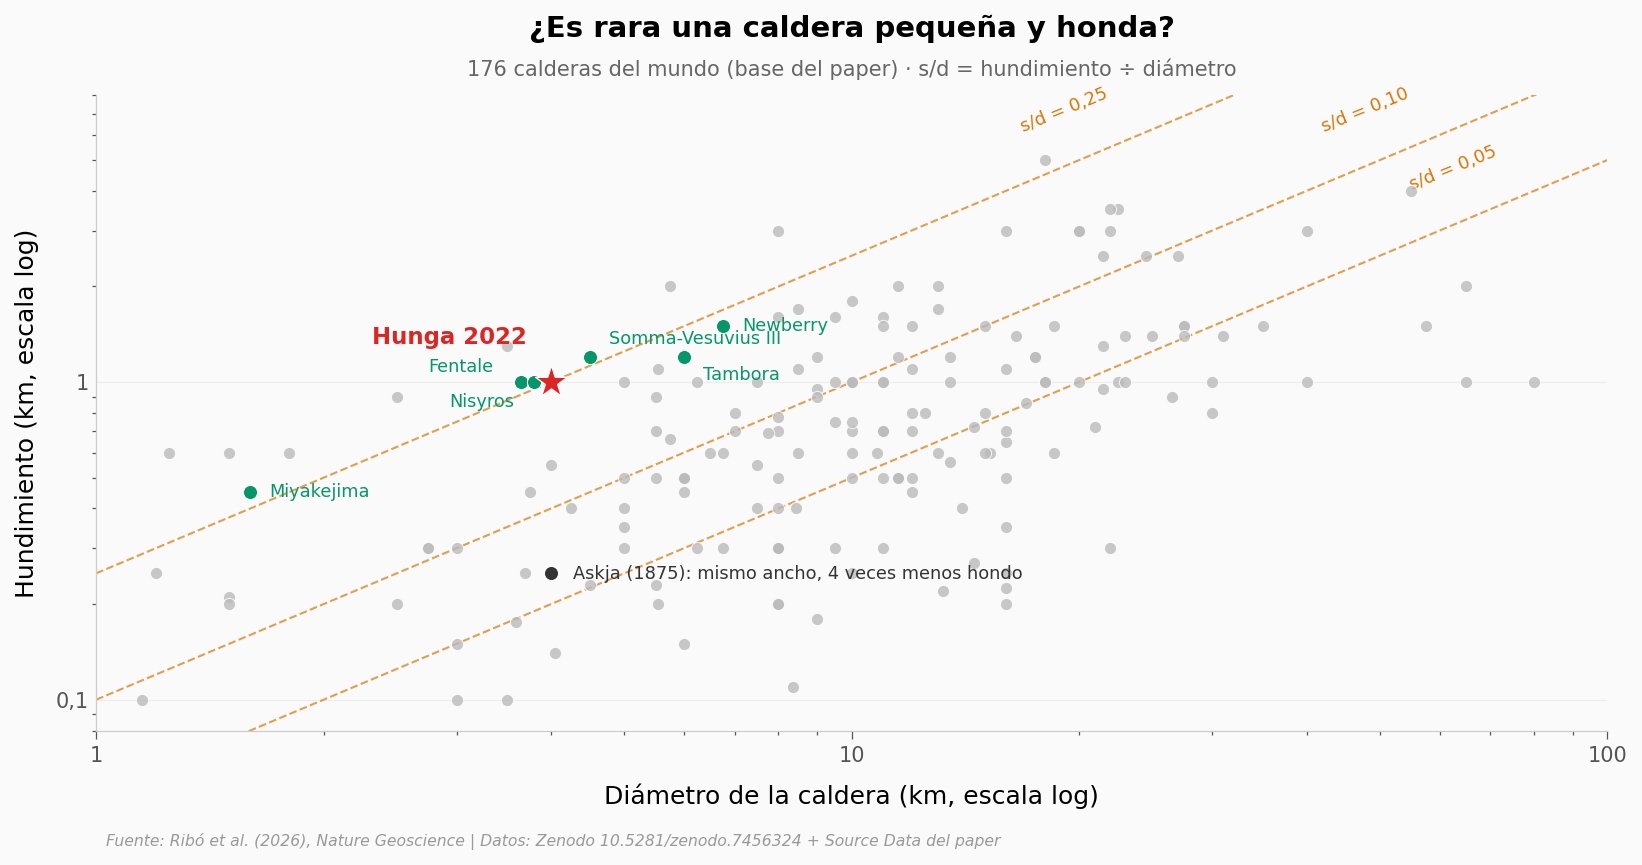

Diámetro: mediana 10 km, IQR 6–16 km, máximo 80 km, asimetría (skew) 2.8
Calderas más pequeñas que Hunga: 22 de 177 = 12.4%
Hundimiento: media 0.95 km, mediana 0.71 km, IQR 0.40–1.20 km · Hunga: 1.0 km
Vecinas en s/d: Tambora 0.20, Newberry 0.22, Nisyros 0.26, Somma-Vesuvius III 0.27, Fentale 0.27, Miyakejima 0.28


In [4]:
vecinas = ['Nisyros', 'Somma-Vesuvius III', 'Fentale', 'Miyakejima', 'Newberry', 'Tambora']
askja_4 = otras[(otras.caldera == 'Askja') & (otras.diam_prom_km == 4.0)].iloc[0]

fig, ax = plt.subplots(figsize=(13, 5.5))

# Líneas de igual relación hundimiento/diámetro
d_lin = np.array([1, 100])
for ratio, d_lab, etiqueta in [(0.05, 72, 's/d = 0,05'), (0.10, 55, 's/d = 0,10'), (0.25, 22, 's/d = 0,25')]:
    ax.plot(d_lin, ratio * d_lin, color=COLOR_REFERENCIA, lw=1, ls='--', alpha=0.7, zorder=2)
    ax.text(d_lab, ratio * d_lab * 1.12, etiqueta, fontsize=8.5, color=COLOR_REFERENCIA, ha='right', rotation=22)

ax.scatter(otras.diam_prom_km, otras.subsidencia_km, color=COLOR_CONTEXTO, s=34, alpha=0.8,
           edgecolors='white', linewidths=0.5, zorder=3)
vec = otras[otras.caldera.isin(vecinas)]
ax.scatter(vec.diam_prom_km, vec.subsidencia_km, color=COLOR_SECUNDARIO, s=46,
           edgecolors='white', linewidths=0.5, zorder=4)
for _, fila in vec.iterrows():
    dx, dy = (1.06, 1.0)
    if fila.caldera == 'Nisyros':
        dx, dy = (0.94, 0.87)
    elif fila.caldera == 'Fentale':
        dx, dy = (0.92, 1.12)
    elif fila.caldera == 'Somma-Vesuvius III':
        dx, dy = (1.06, 1.14)
    elif fila.caldera == 'Tambora':
        dx, dy = (1.06, 0.88)
    ax.text(fila.diam_prom_km * dx, fila.subsidencia_km * dy, fila.caldera, fontsize=8.5,
            color=COLOR_SECUNDARIO, ha='left' if dx > 1 else 'right', va='center')
ax.scatter([askja_4.diam_prom_km], [askja_4.subsidencia_km], color='#333333', s=46,
           edgecolors='white', linewidths=0.5, zorder=4)
ax.text(askja_4.diam_prom_km * 1.07, askja_4.subsidencia_km, 'Askja (1875): mismo ancho, 4 veces menos hondo',
        fontsize=8.5, color='#333333', va='center')

ax.scatter([hunga.diam_prom_km], [hunga.subsidencia_km], marker='*', s=260, color=COLOR_ALERTA,
           edgecolors='white', linewidths=0.6, zorder=6)
ax.text(hunga.diam_prom_km * 0.93, hunga.subsidencia_km * 1.32, 'Hunga 2022', fontsize=11,
        fontweight='bold', color=COLOR_ALERTA, ha='right')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 100)
ax.set_ylim(0.08, 8)
for eje in (ax.xaxis, ax.yaxis):
    eje.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'.replace('.', ',')))
ax.set_xlabel('Diámetro de la caldera (km, escala log)')
ax.set_ylabel('Hundimiento (km, escala log)')
ax.set_title('¿Es rara una caldera pequeña y honda?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(otras)} calderas del mundo (base del paper) · s/d = hundimiento ÷ diámetro',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/calderas_globales.png', dpi=200, bbox_inches='tight')
plt.show()

pct_menores = 100 * (calderas.diam_prom_km < hunga.diam_prom_km).mean()
n_menores = (calderas.diam_prom_km < hunga.diam_prom_km).sum()
print(f'Diámetro: mediana {otras.diam_prom_km.median():.0f} km, IQR {otras.diam_prom_km.quantile(0.25):.0f}–{otras.diam_prom_km.quantile(0.75):.0f} km, '
      f'máximo {otras.diam_prom_km.max():.0f} km, asimetría (skew) {stats.skew(otras.diam_prom_km):.1f}')
print(f'Calderas más pequeñas que Hunga: {n_menores} de {len(calderas)} = {pct_menores:.1f}%')
print(f'Hundimiento: media {otras.subsidencia_km.mean():.2f} km, mediana {otras.subsidencia_km.median():.2f} km, '
      f'IQR {otras.subsidencia_km.quantile(0.25):.2f}–{otras.subsidencia_km.quantile(0.75):.2f} km · Hunga: {hunga.subsidencia_km:.1f} km')
print('Vecinas en s/d:', ', '.join(f'{f.caldera} {f.s_d:.2f}' for _, f in vec.sort_values('s_d').iterrows()))

## ¿Qué tan honda para su tamaño?

Por diámetro, Hunga es de las chicas: 22 de las 177 calderas son más pequeñas (12,4%), y la mediana global es de 10 km. Por hundimiento está cerca del promedio: 1,0 km frente a una media de 0,95 km. Lo raro es la combinación. Comprimamos las dos cosas en un solo número —hundimiento dividido por diámetro— y miremos la distribución.

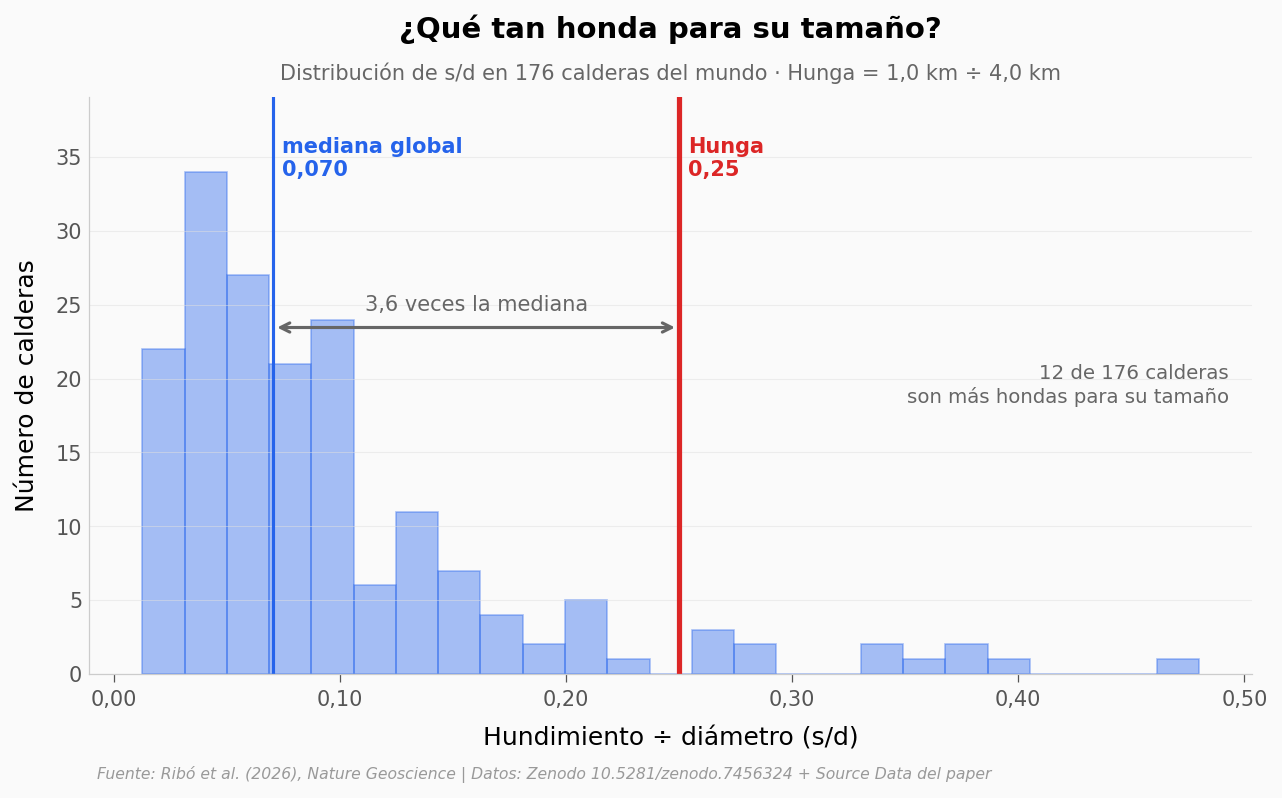

s/d global: mediana 0.070, IQR 0.043–0.115 (n = 176)
Hunga s/d = 0.25 → 93.2% de las calderas quedan por debajo; 12 por encima
Calderas < 10 km: 83; con relación de aspecto conocida: 30 → mediana 0.50, media 0.73 · Hunga: 0.5
Magma erupcionado vs diámetro: Spearman ρ = 0.78 (n = 127, p = 1e-27); la tendencia log-log predice 4.1 km³ para 4 km · Hunga: 8 km³


In [5]:
sd = otras.s_d.dropna()
sd_hunga = HUNGA_SUBSID_KM / HUNGA_DIAM_KM
mediana_sd = sd.median()
n_mayores = (sd > sd_hunga).sum()
pct_debajo = 100 * (sd <= sd_hunga).mean()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(sd, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(x=mediana_sd, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(x=sd_hunga, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(sd_hunga, y_max * 0.6), xytext=(mediana_sd, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((sd_hunga + mediana_sd) / 2, y_max * 0.63, f'{sd_hunga / mediana_sd:.1f} veces la mediana'.replace('.', ','),
        fontsize=10, color='#666666', ha='center')
ax.text(mediana_sd + 0.004, y_max * 0.93, f'mediana global\n{mediana_sd:.3f}'.replace('.', ','),
        fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='left', va='top')
ax.text(sd_hunga + 0.004, y_max * 0.93, f'Hunga\n{sd_hunga:.2f}'.replace('.', ','),
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='left', va='top')
ax.text(0.98, 0.5, f'{n_mayores} de {len(sd)} calderas\nson más hondas para su tamaño',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='right', va='center')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.2f}'.replace('.', ',')))
ax.set_xlabel('Hundimiento ÷ diámetro (s/d)')
ax.set_ylabel('Número de calderas')
ax.set_title('¿Qué tan honda para su tamaño?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Distribución de s/d en {len(sd)} calderas del mundo · Hunga = {HUNGA_SUBSID_KM:.1f} km ÷ {HUNGA_DIAM_KM:.1f} km'.replace('.', ','),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_sd.png', dpi=200, bbox_inches='tight')
plt.show()

print(f's/d global: mediana {mediana_sd:.3f}, IQR {sd.quantile(0.25):.3f}–{sd.quantile(0.75):.3f} (n = {len(sd)})')
print(f'Hunga s/d = {sd_hunga:.2f} → {pct_debajo:.1f}% de las calderas quedan por debajo; {n_mayores} por encima')
chicas = otras[otras.diam_prom_km < 10]
print(f'Calderas < 10 km: {len(chicas)}; con relación de aspecto conocida: {chicas.aspect_ratio.notna().sum()} '
      f'→ mediana {chicas.aspect_ratio.median():.2f}, media {chicas.aspect_ratio.mean():.2f} · Hunga: {hunga.aspect_ratio:.1f}')
con_dre = otras.dropna(subset=['diam_prom_km', 'vol_magma_dre_km3'])
rho, p = stats.spearmanr(con_dre.diam_prom_km, con_dre.vol_magma_dre_km3)
ajuste = stats.linregress(np.log10(con_dre.diam_prom_km), np.log10(con_dre.vol_magma_dre_km3))
pred_4km = 10 ** (ajuste.intercept + ajuste.slope * np.log10(hunga.diam_prom_km))
print(f'Magma erupcionado vs diámetro: Spearman ρ = {rho:.2f} (n = {len(con_dre)}, p = {p:.0e}); '
      f'la tendencia log-log predice {pred_4km:.1f} km³ para {hunga.diam_prom_km:.0f} km · Hunga: {hunga.vol_magma_dre_km3:.0f} km³')

Hunga se hundió 0,25 km por cada kilómetro de diámetro: 3,6 veces la mediana global, y solo 12 de 176 calderas superan esa relación. Sus vecinas en la gráfica anterior son Nisyros, Somma-Vesuvius, Fentale, Miyakejima, Newberry y Tambora — las mismas que nombra el paper. Askja, en 1875, tenía exactamente el mismo diámetro y se hundió 4 veces menos.

En lo demás Hunga es una caldera común: su relación de aspecto (0,5) — qué tan grueso es el techo de roca sobre la cámara comparado con el ancho de la caldera — coincide con la mediana de las calderas de menos de 10 km, y los 8 km³ que el paper estima quedan dentro de la nube de calderas observadas — el doble de lo que la tendencia log-log predice para 4 km, pero en una nube tan dispersa que sigue siendo normal. Lo inusual es una sola cosa: pequeña y muy honda. Y el paper apunta a que justamente eso, un bloque angosto cayendo casi un kilómetro bajo el mar, es lo que probablemente amplificó el tsunami. Esa última parte no la podemos medir con estos datos.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El fondo de la caldera pasó de ~150 m a ~850 m de profundidad | ✅ | Corte NW-SE: fondo pre-eruptivo hasta 155 m dentro de ±2 km; después, piso a 826–855 m (IQR en r ≤ 1 km, mediana 848 m), mínimo 860 m. Los 13 sondeos de abril de 2022 lo confirman con otro instrumento: 3 estaciones a 844, 845 y 852 m |
| El hundimiento máximo fue de 800–1.100 m, mayor en el NW | ✅ | 918 m en el corte NW-SE a 50 m; 903 m en la grilla de 100 m, en el cuadrante NW (x = −0,56, y = +0,66 km). El cuadrante NW tiene la mayor media (−400 m) |
| El hundimiento promedio fue de ~1.000 m | ⚠️ | Ese promedio es *estructural*: el paper lo estima con sísmica, sumando ~150 m de relleno piroclástico bajo el piso actual. Los modelos del fondo solo ven la superficie del relleno (~850 m); el piso de roca a ~1.000 m no es medible aquí |
| Al colapso se atribuyen 6,85 ± 0,05 km³ | ✅ | 6,97 km³ perdidos en r ≤ 4 km sumando celdas (6,85 km³ ignorando cambios < 20 m). El paper usa un modelo armónico cilíndrico; métodos distintos, +1,7% de diferencia |
| El volumen total desplazado fue 8,9 ± 0,1 km³ | ⚠️ | No reproducible: 1,2 km³ corresponden a erosión del flanco sur, fuera de la ventana de ±5 km. En nuestra ventana se perdieron 7,49 km³ y se ganaron 0,17 km³ |
| El diámetro creció marginalmente, de ~4,5 a 4,8 km | ⚠️ | Depende de dónde se mida: 4,8 km de borde a borde en el corte NW-SE (4,7 en E-W, 5,15 en N-S), pero 3,55–4,05 km al contorno de 150 m. El "diámetro estructural" de 4 km del paper es el que entra en la base global. No tenemos cómo medir el "antes" con el mismo criterio |
| Hunga está en el ~12% inferior de 177 calderas por diámetro | ✅ | 22 de 177 son más pequeñas: 12,4% exacto |
| Su relación hundimiento/diámetro (0,25) es mayor que la de la mayoría, similar a Newberry, Somma-Vesuvius, Nisyros, Fantale y Miyakejima | ✅ | 93,2% de las 176 calderas quedan por debajo; vecinas a 0,20–0,28. "Fantale" figura como *Fentale* en la base (0,27) |
| Con relación de aspecto 0,5, Hunga está "en el promedio global" de las calderas < 10 km | ⚠️ | Coincide con la **mediana** (0,50; n = 30 con dato), no con la media (0,73). El paper habla de un subconjunto de 32; en la base hay 30 sin contar Hunga |
| El colapso ocurrió durante la erupción, como un pistón con fallas normales en los bordes | ⚠️ | Es la interpretación de los autores a partir de depósitos de deslizamiento intercalados con el relleno (sísmica) y de las terrazas. El corte muestra los escalones; el orden temporal no sale de un modelo del fondo |
| La velocidad del colapso amplificó el tsunami | ⚠️ | El paper lo enmarca como *probably*; no lo mide ni lo medimos aquí |

> **Limitaciones:** (1) Los dos modelos vienen de campañas con instrumentos distintos (2015-2016 vs cinco campañas de 2022); en los bordes de la ventana, lejos de la caldera, el 20% de las celdas difieren más de 20 m sin que haya pasado nada — de ahí el umbral de ruido. (2) El modelo pre-eruptivo se remuestreó (interpolación bilineal) sobre la grilla del post-eruptivo, y el mapa usa celdas de 100 m (promedio de 2 × 2): suaviza los máximos (903 vs 918 m). (3) La ventana de ±5 km deja fuera la erosión del flanco sur. (4) La base de 177 calderas la construyeron los autores; según ellos, sus valores de hundimiento están probablemente sesgados a la baja porque en muchas solo se conoce el hundimiento geomórfico, no el estructural. Askja aparece dos veces (dos eventos distintos, 9 km y 4 km); no es un duplicado. (5) Los 8 km³ de magma, el ~26% del reservorio y la relación con el tsunami son estimaciones del paper, no cálculos de este notebook.

## Ahora tú

Tres preguntas que puedes responder cambiando un valor arriba:

1. **¿Cuánto cambia el volumen del colapso con el radio?** Sube `RADIO_COLAPSO_KM` a 4,5 o bájalo a 3,5. Si el volumen apenas se mueve, es que casi todo el hundimiento está dentro del borde. Pista: compara con el 6,85 del paper y con los 0,9 km³ que el paper atribuye a erosión de canales fuera de la cuenca.

2. **¿Cuál corte tiene más escalones?** Cambia `PERFIL_HERO` a `'E-W'` o `'N-S'`. El paper dice que la pared NW es casi vertical (~70°) y que las terrazas están en el este y el sur. ¿Se ve la diferencia?

3. **¿Y si el diámetro fuera el del resumen?** El paper mete a Hunga en la base con 4 km (diámetro estructural), pero el resumen habla de 4,8 km. Pon `HUNGA_DIAM_KM = 4.8` y mira cuántas calderas siguen por encima en el histograma.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánta área se hundió más de X metros? Y ¿cuánto del volumen perdido
# viene de las zonas más hondas?
umbrales = [UMBRAL_HUNDIDO_M, 100, 200, 400, 600, 800]
dentro_r = grilla[grilla.r_km <= RADIO_COLAPSO_KM]
vol_total = -dentro_r.loc[dentro_r.cambio_m < 0, 'cambio_m'].sum() * CELDA_KM**2 / 1000

print(f'{"bajó más de":>12} {"área (km²)":>11} {"diám. equiv. (km)":>18} {"volumen (km³)":>14} {"% del total":>12}')
for u in umbrales:
    zona = dentro_r[dentro_r.cambio_m < -u]
    area = len(zona) * CELDA_KM**2
    d_eq = 2 * np.sqrt(area / np.pi)          # diámetro del círculo con la misma área
    vol = -zona.cambio_m.sum() * CELDA_KM**2 / 1000
    print(f'{u:>9} m {area:>11.1f} {d_eq:>18.2f} {vol:>14.2f} {100 * vol / vol_total:>11.0f}%')

hundida = dentro_r[dentro_r.cambio_m < -UMBRAL_HUNDIDO_M].cambio_m
print()
print(f'Zona que bajó más de {UMBRAL_HUNDIDO_M} m: {len(hundida):,} celdas'.replace(',', '.'),
      f'· mediana {hundida.median():.0f} m · IQR {hundida.quantile(0.25):.0f}…{hundida.quantile(0.75):.0f} m'
      f' · asimetría {stats.skew(hundida):.2f} (cola hacia lo hondo: piso a −850 m rodeado de terrazas)')

 bajó más de  área (km²)  diám. equiv. (km)  volumen (km³)  % del total
       50 m        21.0               5.17           6.51          93%
      100 m        13.5               4.14           5.96          86%
      200 m        10.3               3.61           5.52          79%
      400 m         7.1               3.01           4.59          66%
      600 m         4.3               2.35           3.19          46%
      800 m         1.3               1.28           1.08          15%

Zona que bajó más de 50 m: 2.102 celdas · mediana -185 m · IQR -538…-80 m · asimetría -0.72 (cola hacia lo hondo: piso a −850 m rodeado de terrazas)


---

## Fuentes

**Paper**: [Rapid submarine caldera collapse during the 2022 climactic eruption of Hunga volcano (Tonga)](https://doi.org/10.1038/s41561-026-02099-7)  
*Nature Geoscience, 2026-09-11*

**Supplementary Material**: [Source Data (MOESM2): global calderas database (177 calderas) for 'Rapid submarine caldera collapse...'](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41561-026-02099-7/MediaObjects/41561_2026_2099_MOESM2_ESM.xlsx)  
*Nature Geoscience, 2026-09-11*

**Supplementary Material**: [Source Data (MOESM3): Hunga caldera hydrographic (CTD) stations April & October 2022](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41561-026-02099-7/MediaObjects/41561_2026_2099_MOESM3_ESM.xlsx)  
*Nature Geoscience, 2026-09-11*

**Datos**: [Digital Elevation Models of Hunga Volcano; pre- and post- 15 January 2022 eruption (Mackay, NIWA)](https://doi.org/10.5281/zenodo.7456324)  
*Zenodo — DEM pre (2015-2016) y post (2022) a 50 m, CC BY 4.0*

**Referencias citadas**: [Digital Elevation Models of Hunga Volcano, Tonga, from the MAX2201 voyage, July-August 2022 (10 m caldera DEM — citado, no abierto)](https://doi.org/10.5281/zenodo.10038898)

*26 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Modelos del fondo: Mackay (NIWA), Zenodo, CC BY 4.0. Paper: CC BY-NC-ND 4.0.*